
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [7]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import scipy
import matplotlib.animation as animation

# Solución Numérica de la Ecuación de Schrödinger Radial (Átomo de Hidrógeno)

Partimos de la ecuación de Schrödinger independiente del tiempo en su forma general:

$$-\frac{\hbar^2}{2m} \nabla^2 \psi(\vec{r}) + U(\vec{r})\psi(\vec{r}) = E\psi(\vec{r})$$

## 1. Reducción de 3D a una ecuación efectiva 1D

Para un potencial con simetría esférica como el del átomo de hidrógeno, la función de onda se puede separar. La parte radial $R(r)$ obedece la siguiente ecuación diferencial:

$$\frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial R(r)}{\partial r} \right) - \frac{2\mu}{\hbar^2}\left( \frac{Q}{r} - E \right)R(r) = \frac{l(l+1)}{r^2} R(r)$$

Donde hemos sustituido la masa $m$ por la masa reducida $\mu$ del sistema protón-electrón, y el potencial electrostático está dado por $V(r) = \frac{Q}{r}$ con:

$$Q = -\frac{e^2}{4\pi\epsilon_0}$$

Para simplificar esta ecuación y llevarla a una forma análoga a la de 1D, introducimos el cambio de variable **$u(r) = r R(r)$**. Al aplicar este cambio y reorganizar los términos, la ecuación se reescribe como:

$$-\frac{\hbar^2}{2\mu} \frac{d^2 u(r)}{dr^2} + \left( \frac{Q}{r} + \frac{l(l+1)\hbar^2}{2\mu r^2} \right) u(r) = E u(r)$$

Notemos que esta ecuación tiene **exactamente la misma forma** que la ecuación de Schrödinger en 1D:
$$-\frac{\hbar^2}{2\mu} \frac{d^2 \psi(x)}{dx^2} + U_{eff}(x)\psi(x) = E\psi(x)$$

Donde nuestro potencial efectivo es $U_{eff}(r) = \frac{Q}{r} + \frac{l(l+1)\hbar^2}{2\mu r^2}$. Para el estado fundamental ($l=0$), el término centrífugo desaparece y el potencial efectivo es simplemente el potencial de Coulomb $U(r) = -\frac{e^2}{4\pi\epsilon_0}\frac{1}{r}$.

## 2. Aproximación por el Método de Diferencias Finitas (FDM)

Ya que hemos reducido el problema a una dimensión radial $r$, podemos resolverlo numéricamente aproximando la segunda derivada utilizando el método de diferencias finitas centrales:

$$\frac{d^2 u(r)}{dr^2} \approx \frac{u(r + \Delta r) + u(r - \Delta r) - 2u(r)}{(\Delta r)^2}$$

Sustituyendo esta aproximación en nuestra ecuación de Schrödinger radial efectiva obtenemos:

$$-\frac{\hbar^2}{2\mu} \left( \frac{u(r + \Delta r) + u(r - \Delta r) - 2u(r)}{(\Delta r)^2} \right) + U(r)u(r) \approx E u(r)$$

## 3. Discretización y Problema de Autovalores

Para implementarlo en código, discretizamos el espacio radial en puntos $r_i$, de modo que $u(r_i) = u_i$ y $U(r_i) = U_i$. Multiplicando toda la ecuación por el factor que acompaña a la derivada, definimos la constante geométrica de nuestra malla:

$$k = \frac{2\mu(\Delta r)^2}{\hbar^2}$$

Reorganizando la ecuación para cada punto $i$ de la malla, obtenemos la forma discretizada final que utilizaremos para construir la matriz Hamiltoniana:

$$-(u_{i+1} + u_{i-1} - 2u_i) + k \cdot U_i u_i = k \cdot E u_i$$

Donde $U_i = -\frac{e^2}{4\pi\epsilon_0} \frac{1}{r_i}$ para estados $s$ ($l=0$). Esta ecuación nos permite plantear el problema como un sistema algebraico matricial $H \vec{u} = E \vec{u}$ para encontrar las energías permitidas $E$ y las funciones de onda $u(r)$.


## 4. Construcción de la Matriz Hamiltoniana

A partir de nuestra ecuación discretizada, si agrupamos los términos y factorizamos $-\frac{1}{k}$, la ecuación para un punto $i$ de la malla se puede reescribir como:

$$-\frac{1}{k}u_{i-1} - \frac{1}{k}(-2 - k U_i)u_i - \frac{1}{k}u_{i+1} \approx E u_i$$

Para ilustrar cómo se forma el sistema de ecuaciones, consideremos una malla pequeña de cinco puntos espaciales $r = \{r_0, r_1, r_2, r_3, r_4\}$. 

Aplicamos las **condiciones de frontera** (boundary conditions) de la función de onda radial. Sabemos que la función debe anularse en los extremos:
* En el origen ($r_0 = 0$): $u_0 = 0$ (ya que $u(r) = r R(r)$).
* En el infinito ($r_4 \to \infty$): $u_4 = 0$ (la función de onda debe decaer para estados ligados).

Sustituyendo esto, las ecuaciones para los puntos interiores ($i=1, 2, 3$) quedan así:

$$-\frac{1}{k} \left( \cancel{u_0} + (-2 - k U_1)u_1 + u_2 \right) = E u_1$$
$$-\frac{1}{k} \left( u_1 + (-2 - k U_2)u_2 + u_3 \right) = E u_2$$
$$-\frac{1}{k} \left( u_2 + (-2 - k U_3)u_3 + \cancel{u_4} \right) = E u_3$$

Podemos reescribir este sistema de ecuaciones lineales en forma matricial, lo que nos revela una **matriz tridiagonal**:

$$
\frac{1}{k}
\begin{bmatrix}
2 + k U_1 & -1 & 0 \\
-1 & 2 + k U_2 & -1 \\
0 & -1 & 2 + k U_3
\end{bmatrix}
\begin{pmatrix}
u_1 \\
u_2 \\
u_3
\end{pmatrix}
= E
\begin{pmatrix}
u_1 \\
u_2 \\
u_3
\end{pmatrix}
$$

Esta es la forma estándar de un problema de autovalores $H \vec{u} = E \vec{u}$. 
* La matriz representa nuestro **Operador Hamiltoniano ($H$)** discretizado.
* Los autovalores ($E$) serán los niveles de energía cuantizados del átomo de hidrógeno.
* Los autovectores ($\vec{u}$) corresponderán a las funciones de onda radiales efectivas evaluadas en los puntos de la malla.

In [8]:
# Parámetros físicos
L = 60      # Tamaño de la caja en radios de Bohr (a_0)
hbar = 1.0
m = 1.0

N = 500        
r_grid = np.linspace(0, L, N)
dr = r_grid[1] - r_grid[0]
dr2 = dr * dr

# Factor k definido: k = (2 * m * dr^2) / hbar^2
k = (2.0 * m * dr2) / (hbar**2)

# Excluimos r=0 y r=L para aplicar condiciones de frontera (u(0)=0 y u(L)=0)
r = r_grid[1:-1]
N_int = len(r)


H = np.zeros((N_int, N_int))
for i in range(N_int):
    U_i = -1.0 / r[i]  
    H[i, i] = (2.0 + k * U_i) / k
    if i > 0:
        H[i, i - 1] = -1.0 / k
        H[i - 1, i] = -1.0 / k
E, psi = np.linalg.eigh(H)

print("Primeros 3 niveles de energía (Hartrees):", E[:3])

Primeros 3 niveles de energía (Hartrees): [-0.49820573 -0.12488725 -0.05553326]


Trapezoidal Area: 0.11991394853963884


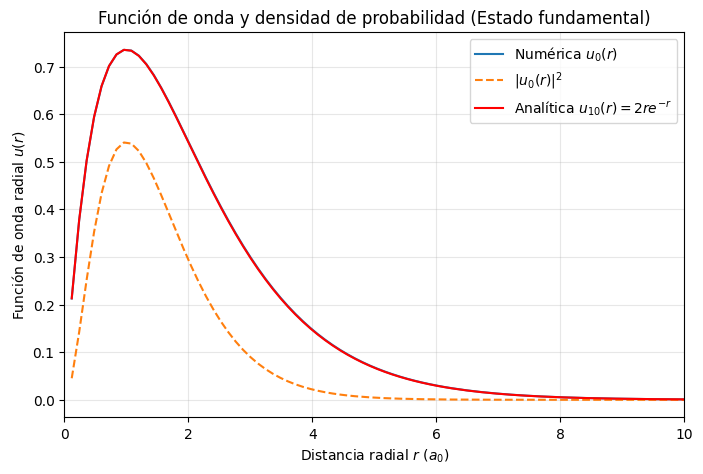

In [9]:
u_num = psi[:, 0]

if u_num[np.argmax(np.abs(u_num))] < 0:
    u_num = -u_num


area_trap = np.trapezoid(u_num**2, x=r)
print(f"Trapezoidal Area: {area_trap}")


u_norm = u_num / np.sqrt(area_trap)

# Solución analítica (n=1, l=0)
u_analitica = 2.0 * r * np.exp(-r)


plt.figure(figsize=(8, 5))
plt.plot(r, u_norm, label=r'Numérica $u_0(r)$')
plt.plot(r, u_norm**2, linestyle="--", label=r'$|u_0(r)|^2$')
plt.plot(r, u_analitica, 'r-', linewidth=1.5, label=r'Analítica $u_{10}(r) = 2re^{-r}$')
plt.xlabel(r'Distancia radial $r$ ($a_0$)')
plt.ylabel(r'Función de onda radial $u(r)$')
plt.title('Función de onda y densidad de probabilidad (Estado fundamental)')
plt.legend()
plt.xlim(0, 10)  
plt.grid(True, alpha=0.3)
plt.show()

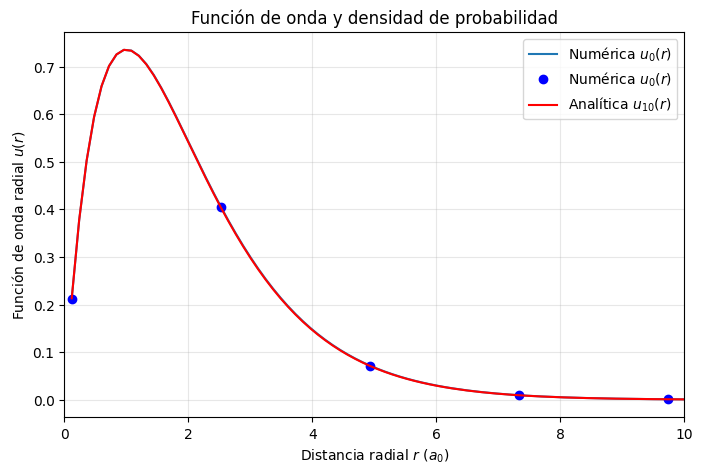

In [10]:
n=20
plt.figure(figsize=(8, 5))
plt.plot(r, u_norm, label=r'Numérica $u_0(r)$')
plt.plot(r[::n], u_norm[::n], 'bo', label=r'Numérica $u_0(r)$')
plt.plot(r, u_analitica, 'r-', label=r'Analítica $u_{10}(r)$')

plt.xlabel(r'Distancia radial $r$ ($a_0$)')
plt.ylabel(r'Función de onda radial $u(r)$')
plt.title('Función de onda y densidad de probabilidad')
plt.legend()
plt.xlim(0, 10)  
plt.grid(True, alpha=0.3)
plt.show()

#### Densidad de probabilidad radial para el átomo de Hidrogeno  

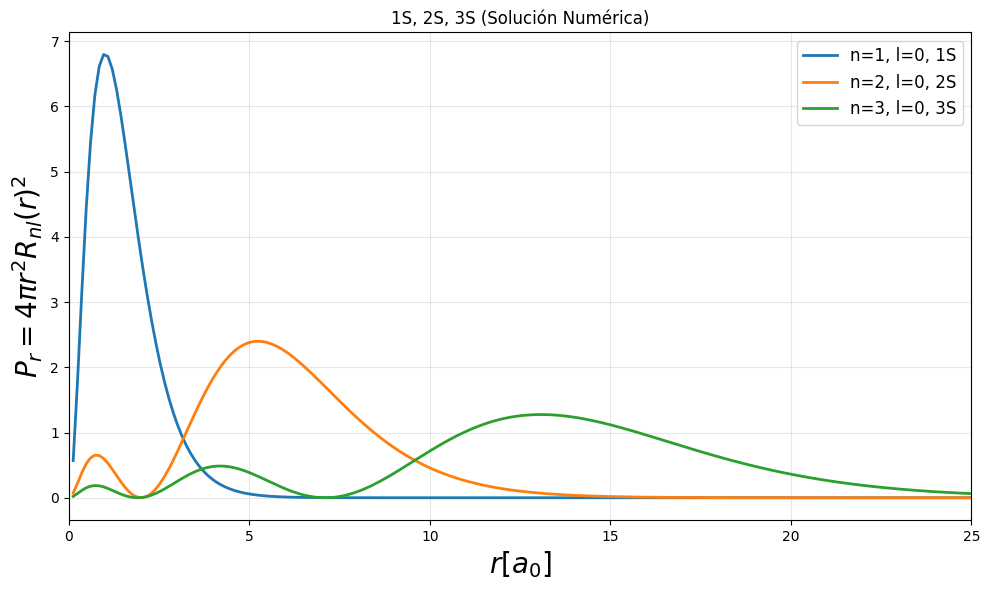

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))


# Nombres de los estados
estados = ['1S', '2S', '3S']


for n in range(3):
    u_n = psi[:, n]  
    if u_n[np.argmax(np.abs(u_n))] < 0:
        u_n = -u_n

    area = np.trapezoid(u_n**2, x=r)
    u_norm = u_n / np.sqrt(area)
    P_r = 4 * np.pi * u_norm**2
    ax.plot(r, P_r, lw=2, label=f'n={n+1}, l=0, {estados[n]}')




ax.set_xlabel(r'$r [a_0]$', fontsize=20)
ax.set_ylabel(r'$P_r = 4\pi r^2 R_{nl}(r)^2$', fontsize=20)
ax.set_title('1S, 2S, 3S (Solución Numérica)')
ax.set_xlim(0, 25)
ax.legend(fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

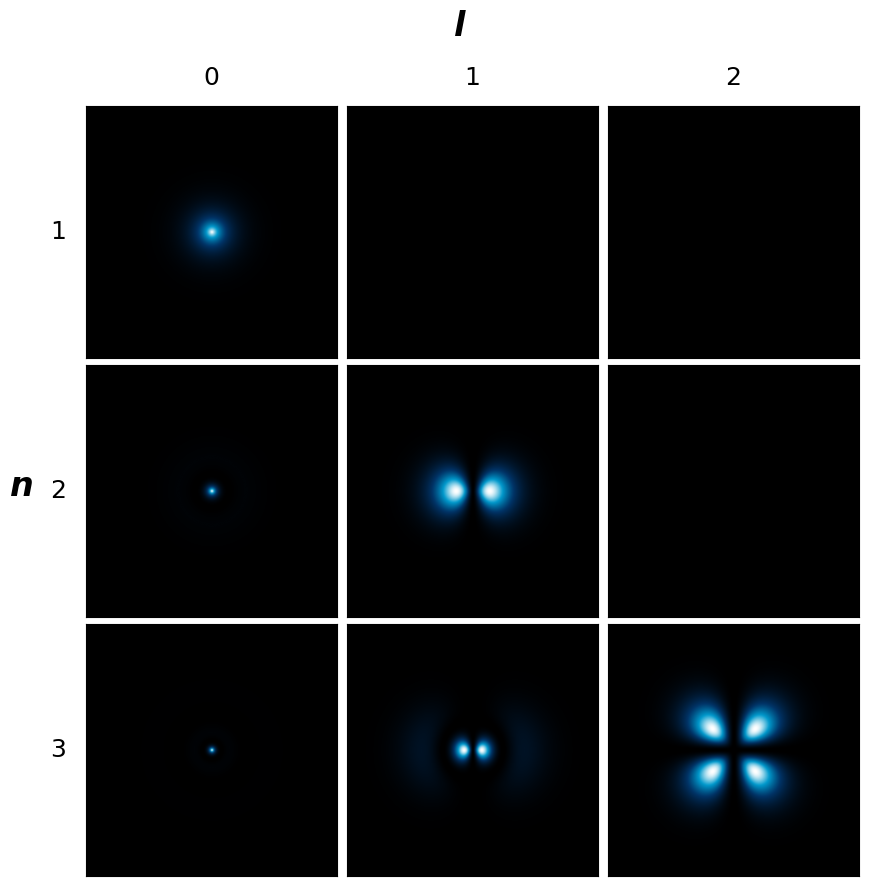

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre
from matplotlib.colors import LinearSegmentedColormap




colores = [(0, 0, 0), (0, 0.2, 0.4), (0, 0.6, 0.8), (1, 1, 1)]
cmap_cyan = LinearSegmentedColormap.from_list('orbital_cyan', colores)

#   Función analítica de la densidad de probabilidad 
def densidad_orbital(n, l, limite, puntos=400):
    # Creamos la malla espacial
    x = np.linspace(-limite, limite, puntos)
    z = np.linspace(-limite, limite, puntos)
    X, Z = np.meshgrid(x, z)
    
    # Coordenadas polares (r, theta) en el plano y=0
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R == 0, 1e-10, R) 
    
    rho = 2.0 * R / n
    
    # PARTE RADIAL (Polinomios de Laguerre)
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)
    parte_radial = (rho**l) * np.exp(-rho / 2.0) * laguerre(rho)
    
    # PARTE ANGULAR (Armónicos Esféricos simplificados para el plan XZ
    if l == 0:
        parte_angular = 1.0                          
    elif l == 1:
        parte_angular = X / R                            
    elif l == 2:
        parte_angular = (X * Z) / R**2                   


    psi = parte_radial * parte_angular
    densidad = psi**2
    return densidad / np.max(densidad)


fig, axes = plt.subplots(3, 3, figsize=(10, 10), facecolor='white')
plt.subplots_adjust(wspace=0.03, hspace=0.03) 

limites_n = [5, 15, 25]


for fila, n in enumerate([1, 2, 3]):
    for col, l in enumerate([0, 1, 2]):
        ax = axes[fila, col]
        
        
        if l >= n:
            ax.imshow(np.zeros((10, 10)), cmap='gray', vmin=0, vmax=1)
        else:
            densidad = densidad_orbital(n, l, limites_n[fila])
            ax.imshow(densidad, 
                      extent=[-limites_n[fila], limites_n[fila], -limites_n[fila], limites_n[fila]], 
                      origin='lower', 
                      cmap=cmap_cyan, 
                      interpolation='bicubic')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        if fila == 0:
            ax.set_title(f"{l}", fontsize=18, pad=15)
        if col == 0:
            ax.set_ylabel(f"{n}", fontsize=18, rotation=0, labelpad=20, va='center')


fig.text(0.5, 0.95, "l", ha='center', fontsize=24, fontweight='bold', style='italic')
fig.text(0.05, 0.5, "n", va='center', fontsize=24, fontweight='bold', style='italic')

plt.show()